**TAREFAS**:

Ajustar os data types carlota\
Fazer os boxplots menos largos carlota - rever estutura all missing values \
explicar melhor como separamos city de country\

verfiicar o datatype de cada coluna e mudar oq tem a ser udado ANTES DO MULTIINDEX mas dps dos missing values

**DÚVIDAS:** \
**OS NOMES DOS PAÍSES ESTÃO COM UM ESPAÇO ATRÁS**

\
nas guidelines fala que nas perguntas temos que aprofundar bué e nao só surface level. **MELHORAR CONCLUSOES**

cenas que queremos meter uma varibale called cost of living meter average rent



<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">

<h1 style="margin-bottom:0;"><b>Programming for Data Science  - Group Project </b></h1>

<h1 style="margin-top:5px; color:#357AF6;"><b>“Where Should I Live?” </b></h1>

<h2 style="color:#357AF6; margin-top:-5px;"><b>Leveraging Data to Optimize Quality of Life Choices</b></h2>

<br>

<h3><b>Group 19</b></h3>

<ul style="margin-top:-10px;">
<li><b>Carlota Marto</b> — 20241729</li>
<li><b>Henrique Santos</b> — 20241752</li>
<li><b>Laura Lisboa</b> — 20241783</li>
<li><b>Tiago Carvalho</b> — 20241728</li>
</ul>

<br>

<h4>LCD  —  Teachers: Carina Albuquerque / Sofia Pereira  — 2025/26 </h4>

</div>



<div style="background-color:#EFF5FF; padding:15px; border-radius:10px;">

    
**Table of Contents**

**1.Introduction**

1.1. Project Goal and Organization

**2. Data Wrangling and Exploratory Analysis**

2.1. Imports\
2.2. Preprocessing Data
<ul style="margin-top:-10px;">
    
  2.2.1. Handling Inconsistencies \
  2.2.2  Adjusting Data Types\
  2.2.3. Duplicate Records\
  2.2.4. Missing Values - Categorical(1) / Numerical (2-6) \
  2.2.5  Separating Cities and Countries
</ul>

2.3. Questions Section – 1 to 4

**3. Advanced Topics**

3.1. Advanced Data Acquisition (Web Scraping)\
3.2. Geospatial Data Integration and Visualization\


**4. Data Science in Action: Framework and Conclusion**

4.1. Multivariate Analysis and Relationship Exploration\
4.2. Country Segmentation (Clustering)\
4.3. The Final Decision Framework\
4.4. Conclusion and Actionable Recommendationsnd Actionable Recommendations
</div>





<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">
<h3><b>1. Introduction </b></h3>


 <div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b> 1.1. Project Goal and Organization

The primary goal of this Notebook is to perform a **comprehensive**, **data-driven analysis** to empower users in making **informed** living decisions across European countries.\
This project aims to **simplify** the complex choice of where to live by analysing key national characteristics—such as Cost of Living, Population Density, and Employment—and translating **raw data into an interpretable framework**.

Ultimately, this project seeks to answer the central question:\
**Which European countries offer the optimal alignment with a user's personal values and life goals, based on quantitative metrics?**

-------

The project is structured into **three phases**, from raw data preparation to actionable conclusions:
<ul style="margin-top:-10px;">

**-Data Wrangling and Analysis:** Focus on transforming raw data into clean, structured datasets through fundamental exploration techniques to extract relevant initial insights;\
**-Working with Advanced Topics:** Focus on integrating advanced and diverse data sources (e.g., web scraping or geographical data) to reflect the complexity of real-world data collection challenges;\
**-Data Science in Action:** Focus on synthesizing all previous work into a coherent, high-level analysis. The final output is an actionable framework that explores patterns, visualizes relationships, and provides clear, critical conclusions about European living choices.




<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">
<h3><b>2. Data Wrangling and Exploratory Analysis </b></h3>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.1 Imports
   

Import of Necessary Libraries:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup                # process html
from selenium import webdriver               # automate web browser interaction
from selenium.webdriver.common.by import By  #specify specify how to locate elements on a web page.
import requests 

Import of the given Dataset:

In [2]:
dataset = pd.read_csv('city_data.csv', sep = '|', header = 1, index_col = 0)
dataset.head()

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00
"Salzburg, Austria",243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,NaN,2023-11-03 00:00:00
"Brussels, Belgium",681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,NaN,2023-04-22 00:00:00
"Antwerp, Belgium",928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,NaN,2024-08-09 00:00:00
"Gent, Belgium",552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,120.0,2023-07-17 00:00:00


<div style="background-color:#357AF6; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2 Preprocessing Data
   

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.1 Handling Inconsistencies

In [3]:
dataset.columns #This line allows us to see the name of all the columns of the dataset

Index(['Population Density', 'Population', 'Working Age Population ',
       'Youth Dependency Ratio', 'Unemployment Rate', 'GDP per Capita',
       'Days of very strong heat stress', 'Main Spoken Languages',
       'Average Monthly Salary', 'Avgerage Rent Price',
       'Average Cost of Living', 'Average Price Groceries',
       'Last Data Update'],
      dtype='object')

We can observe that the column **'Working Age Population '** has a space in front, which can make it confusing to code with. Also, the column **'Avgerage Rent Price'** has a spelling mistake which we are going to correct.

While analyzing the Project Data table presented in the Project Guidelines, we also decided to change the name of some columns to clear understanding and precisison. 

In [4]:
dataset = dataset.rename(columns={'Population Density': 'Population Density (/km2)', 
                                  'Working Age Population ': 'Working Age Population (15-64 years)',
                                  'GDP per Capita': 'GDP per Capita ($)',
                                  'Days of very strong heat stress' : 'Days of very strong heat stress (>38ºC)',
                                  'Average Monthly Salary': 'Average Monthly Salary (€)', 
                                  'Avgerage Rent Price' : 'Average Rent Price (€)',
                                 })

In [5]:
dataset.head(1)

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita ($),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00


The variable **'GDP per Capita'** is measured in $ and, as there are other two columns where the values are measured in €,so, we are going to do the conversion of all the values in that column. We are sure that, that way, it is less confusing for someone trying to find the best place to live.\

For **simplicity**, we are going to consider the cost of 1 dolar equal to 0.87 euros (present price) and **not** the price of 1 dolar in euros in the given date of last data update for each city. 

In [6]:
dataset['GDP per Capita ($)'] = dataset['GDP per Capita ($)'] * 0.87  

In [7]:
dataset = dataset.rename(columns={'GDP per Capita ($)' : 'GDP per Capita (€)'})
dataset.head(1)

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,48519.9,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.2 Adjusting Data Types

In [8]:
dataset.info()
#this line allows us to see the datatype of each column

<class 'pandas.core.frame.DataFrame'>
Index: 86 entries, Vienna, Austria to Adana, Turkiye
Data columns (total 13 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Population Density (/km2)                85 non-null     float64
 1   Population                               86 non-null     int64  
 2   Working Age Population (15-64 years)     85 non-null     float64
 3   Youth Dependency Ratio                   86 non-null     float64
 4   Unemployment Rate                        85 non-null     float64
 5   GDP per Capita (€)                       85 non-null     float64
 6   Days of very strong heat stress (>38ºC)  86 non-null     int64  
 7   Main Spoken Languages                    85 non-null     object 
 8   Average Monthly Salary (€)               86 non-null     int64  
 9   Average Rent Price (€)                   86 non-null     int64  
 10  Average Cost of Living         

&nbsp;&nbsp;&nbsp;&nbsp;As we can see, there are some columns classified as 'float64' that do not make sense. For example, the Working Age Population and the GDP per Capita. We decided to change them to integers to make it easier to read. (Average Price Groceries also has that problem but we chose to ignore it for now because it is going to be removed.)

**Adjusted Data Types:**

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.3. How to Handle Duplicate Records

We chose to handle the **duplicate records firstly** so that those records do not interfere with the imputation of the missing values.

In [9]:
duplicate_records = dataset[dataset.duplicated(keep = False)]
duplicate_records
#these two lines shows us the duplicate records in the dataset

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
Berlin. Germany,304.0,5303922,3481212.0,21.3,4.7,40496.76,3,"German, Turkish, Arabic, English",3200,1220,2200,NaN,2023-06-29 00:00:00
Berlin. Germany,304.0,5303922,3481212.0,21.3,4.7,40496.76,3,"German, Turkish, Arabic, English",3200,1220,2200,NaN,2023-06-29 00:00:00
"Malaga, Spain",571.0,869096,585608.0,23.5,17.7,24093.78,0,"Spanish, English",2200,1312,1400,NaN,2023-11-27 00:00:00
"Malaga, Spain",571.0,869096,585608.0,23.5,17.7,24093.78,0,"Spanish, English",2200,1312,1400,NaN,2023-11-27 00:00:00


In the whole dataset we only have two duplicates: Berlin and Malaga. In the next line of code we are removing them.

In [10]:
dataset.drop_duplicates(inplace = True)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.4. How to Handle Missing Values

Firstly, we need to understand how many missing values are in our dataset. With this function, we are able to see how many are in each column.

In [11]:
dataset.isna().sum()

Population Density (/km2)                   1
Population                                  0
Working Age Population (15-64 years)        1
Youth Dependency Ratio                      0
Unemployment Rate                           1
GDP per Capita (€)                          1
Days of very strong heat stress (>38ºC)     0
Main Spoken Languages                       1
Average Monthly Salary (€)                  0
Average Rent Price (€)                      0
Average Cost of Living                      0
Average Price Groceries                    78
Last Data Update                            0
dtype: int64

We can conclude that exist 6 variables with missing values - 1 Categorical and 5 Numerical.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
<b>2.2.4. How to Handle Missing Value - Categorical Variables


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
1. Only in **'Main Spoken Languages'**  is missing a categorical variable - We first need to understand in what row is the missing value located:

In [12]:
dataset[dataset['Main Spoken Languages'].isna()]

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
"Dusseldorf, Germany",1295.0,1554077,NaN,21.4,3.3,61977.06,3,NaN,3200,1100,2050,NaN,2024-01-15 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

As it is a **categorical** variable we have to deal with it with the mode. If we did not have the information about the country of the city, we would apply the mode to all the cities in the dataset, but, as we know that "Dusseldorf" is located in Germany we only apply the mode to all the **german cities** for a more accurate result:

In [13]:
dataset.loc[dataset.index.str.contains('Germany'), ['Main Spoken Languages']].mode()

,Main Spoken Languages
0,German


As we can observe, the most common main spoken language in german cities of the dataset is **'German'**. Therefore, we will replace the missing value with 'German':

In [14]:
dataset.loc['Dusseldorf, Germany', 'Main Spoken Languages'] = 'German'
dataset.loc[['Dusseldorf, Germany']]

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
"Dusseldorf, Germany",1295.0,1554077,NaN,21.4,3.3,61977.06,3,German,3200,1100,2050,NaN,2024-01-15 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
<b>2.2.4. How to Handle Missing Value - Numerical Variables

We can do many things with missing numerical values. There are cases where we must replace with the **median** and others where we must use the **mean**. This all depends if those columns have outliers or not, therefore, we decided that the best way to verify outliers is by creating a **boxplot for each variable**. As the columns with missing values have very different scales, we cannot put them all in the same graphic.\
\
**Note:** As it is preferible to use the mean than median, if there aren´t outliers, we use it, if not, we use the median because this one doesn´t change it´s value when existing outliers. 

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

2. In the column **'Average Price Groceries' there are 80 missing values out of the 86 rows total.** As there are only 6 records of average price groceries, this does not add up any valuable information, therefore, we decided to remove it.  -   Here doesn´t make sense filling the missing values.

In [15]:
dataset.drop('Average Price Groceries', axis = 1, inplace = True)
dataset.head(1) #this is just to visualise that the columns is not there anymore

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,48519.9,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

3. For the missing value in the column **'Working Age Population'**, by the same logic in 1. we will replace it based on the other **german cities** as the only missing value is also located in Dusseldorf in Germany (seen is 1.).


In [16]:
dataset[dataset['Working Age Population (15-64 years)'].isna()]
#Here we can confirm that the only missing value is actually in a german city

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Dusseldorf, Germany",1295.0,1554077,NaN,21.4,3.3,61977.06,3,German,3200,1100,2050,2024-01-15 00:00:00


In [17]:
german_cities = dataset[dataset.index.str.contains('Germany')]
german_cities.head()
#this line creates a new dataset with the information of german cities only

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
Berlin. Germany,304.0,5303922,3481212.0,21.3,4.7,40496.76,3,"German, Turkish, Arabic, English",3200,1220,2200,2023-06-29 00:00:00
"Hamburg, Germany",461.0,3315036,2181857.0,21.5,3.2,53120.46,0,"German, English, Turkish",3500,1100,2100,2024-07-10 00:00:00
"Munich, Germany",529.0,2907752,1955041.0,21.1,2.1,73049.55,1,"German, English",3540,1500,2550,2023-03-16 00:00:00
"Cologne, Germany",1233.0,2002550,1335299.0,20.8,3.9,52469.70,3,"German, English, Turkish",3200,1030,2000,2024-11-23 00:00:00
"Frankfurt am Main, Germany",631.0,2710501,1791435.0,22.0,3.2,60353.64,6,"German, English",3800,1300,2350,2023-02-04 00:00:00


**Verifying the existence of outliers:**

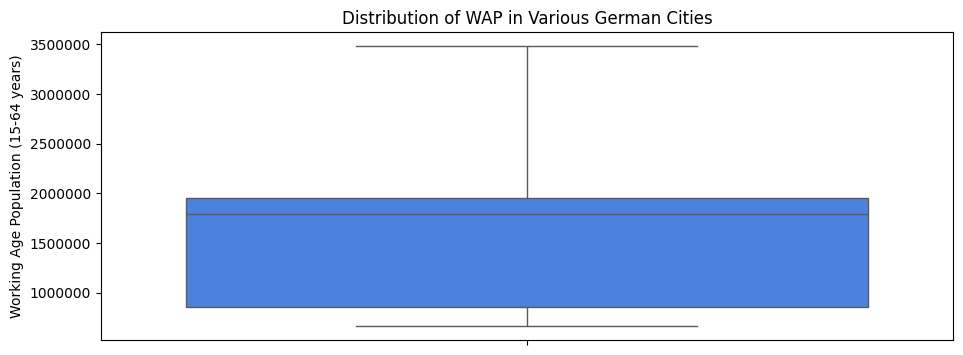

In [18]:
plt.figure(figsize = (11,4))
sns.boxplot(data = german_cities['Working Age Population (15-64 years)'], color ='#357AF6')
plt.title('Distribution of WAP in Various German Cities')
plt.ticklabel_format(style = 'plain', axis = 'y')

**Conclusion:** As we can see above, there are no outliers in the Working Age Population in German cities, therefore we use mean:

In [19]:
dataset.loc['Dusseldorf, Germany', ['Working Age Population (15-64 years)']] =  german_cities['Working Age Population (15-64 years)'].mean().round()
dataset.loc[['Dusseldorf, Germany']]
#This two lines replace the missing value by the mean and display the row with information about Dusseldorf, Germany.

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Dusseldorf, Germany",1295.0,1554077,1658169.0,21.4,3.3,61977.06,3,German,3200,1100,2050,2024-01-15 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
4. Missing Value in **'Population Density':**

In [20]:
dataset[dataset['Population Density (/km2)'].isna()]	
#this line allows us to see what city has the missing value in Population Density

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Valencia, Spain",NaN,1748142,1162828.0,22.6,13.7,29205.9,5,Spanish;Valencian,2400,1190,1300,2023-06-04 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

By the same logic as the last one, we're going to compare Valencia to the other spainish cities and then, see the distribution of the Population Density in those cities:

In [21]:
spanish_cities = dataset[dataset.index.str.contains('Spain')]
spanish_cities.head()
#this line creates a new dataset with the information of german cities only

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Madrid, Spain",873.0,6882461,4617753.0,23.0,10.8,44387.40,18,Spanish,2271,1100,1589,2023-05-14 00:00:00
"Barcelona, Spain",1918.0,5034925,3331345.0,22.6,11.0,39163.92,0,"Spanish, Catalan",2094,1450,1630,2024-10-18 00:00:00
"Valencia, Spain",NaN,1748142,1162828.0,22.6,13.7,29205.90,5,Spanish;Valencian,2400,1190,1300,2023-06-04 00:00:00
"Seville, Spain",330.0,1549641,1037225.0,25.0,21.6,26103.48,53,Spanish,2300,650,1150,2024-09-01 00:00:00
"Malaga, Spain",571.0,869096,585608.0,23.5,17.7,24093.78,0,"Spanish, English",2200,1312,1400,2023-11-27 00:00:00


**Verifying the existence of outliers:**

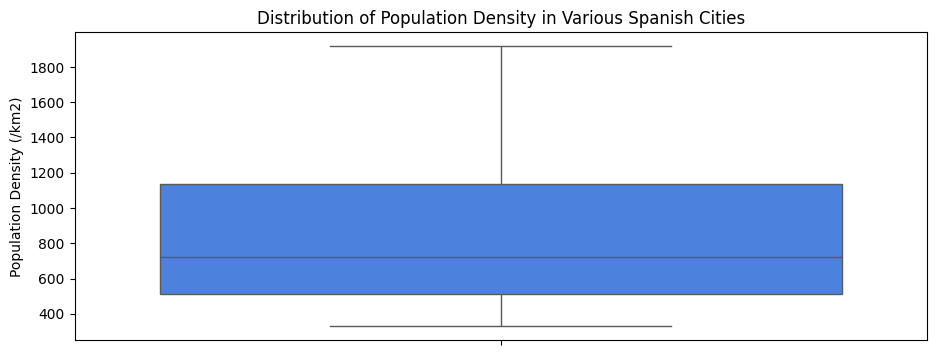

In [22]:
plt.figure(figsize = (11,4))
sns.boxplot(data = spanish_cities['Population Density (/km2)'], color = '#357AF6')
plt.title('Distribution of Population Density in Various Spanish Cities')
plt.ticklabel_format(style = 'plain', axis = 'y')

**Conclusion:** As we can see above, there are no outliers in Population Density in German cities, therefore we use mean:

In [23]:
dataset.loc['Valencia, Spain', ['Population Density (/km2)']] =  spanish_cities['Population Density (/km2)'].mean()
dataset.loc[['Valencia, Spain']]

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Valencia, Spain",923.0,1748142,1162828.0,22.6,13.7,29205.9,5,Spanish;Valencian,2400,1190,1300,2023-06-04 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
5. Missing Value in **'Unemployment Rate':**

In [24]:
dataset[dataset['Unemployment Rate'].isna()]
#this line allows us to see what city has the missing value in Unemployment Rate.


,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Gent, Belgium",552.0,645813,417832.0,24.8,NaN,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17 00:00:00


In [25]:
belgium_cities = dataset[dataset.index.str.contains('Belgium')]
belgium_cities.head()
#this line creates a new dataset with the information of Belgium cities only.

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Brussels, Belgium",681.0,3284548,2137425.0,27.50,10.7,54375.00,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22 00:00:00
"Antwerp, Belgium",928.0,1139663,723396.0,27.70,6.2,50107.65,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09 00:00:00
"Gent, Belgium",552.0,645813,417832.0,24.80,NaN,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17 00:00:00
"Bruges, Belgium",840.0,119765,74600.0,25.63,5.6,54882.21,0,"Dutch, French",2700,1250,1708,2023-10-25 00:00:00


**Verifying the existence of outliers:**

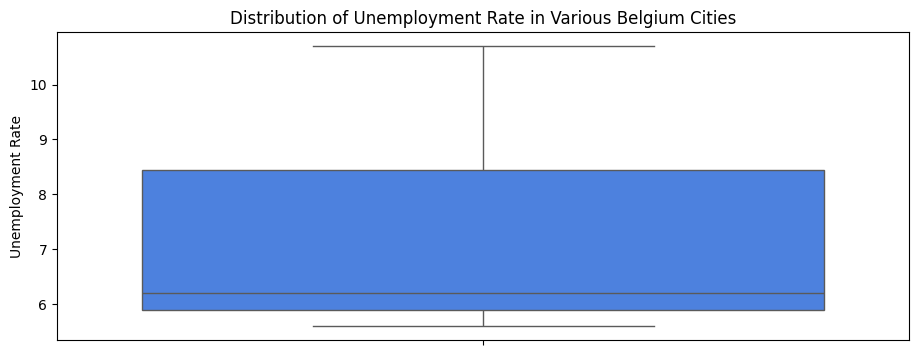

In [26]:
plt.figure(figsize = (11,4))
sns.boxplot(data = belgium_cities['Unemployment Rate'], color = '#357AF6')
plt.title('Distribution of Unemployment Rate in Various Belgium Cities')
plt.ticklabel_format(style = 'plain', axis = 'y')

**Conclusion:** As we can see above, there are no outliers in Unemployment Rate in Belgium cities, therefore we use mean:

In [27]:
dataset.loc['Gent, Belgium', ['Unemployment Rate']] =  belgium_cities['Unemployment Rate'].mean()
dataset.loc[['Gent, Belgium']]

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Gent, Belgium",552.0,645813,417832.0,24.8,7.5,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
6. Missing Value in **'GDP per Capita':**

In [28]:
dataset[dataset['GDP per Capita (€)'].isna()]	
#this line allows us to see what city has the missing value in GDP per Capita.

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
Lemesos;Cyprus,190.0,262238,173906.0,23.06,11.2,NaN,0,"Greek, English, Russian",2500,1400,2300,2023-08-14 00:00:00


In [29]:
cyprus_cities = dataset[dataset.index.str.contains('Cyprus')]
cyprus_cities.head()
#this line creates a new dataset with the information of Cyprus cities only.

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Lefkosia, Cyprus",130.0,356400,237000.0,23.06,9.6,30369.09,45,"Greek, Turkish, English",1486,700,1350,2024-04-08 00:00:00
Lemesos;Cyprus,190.0,262238,173906.0,23.06,11.2,NaN,0,"Greek, English, Russian",2500,1400,2300,2023-08-14 00:00:00



<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

As there are only **two cities in Cyprus**, we can only impute a value in the missing value based on the other city, therefore we decided that we are going to use the same value for both:

In [30]:
dataset.loc['Lemesos;Cyprus', ['GDP per Capita (€)']] =  dataset.loc['Lefkosia, Cyprus', ['GDP per Capita (€)']]
dataset.loc[['Lemesos;Cyprus']]

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
Lemesos;Cyprus,190.0,262238,173906.0,23.06,11.2,30369.09,0,"Greek, English, Russian",2500,1400,2300,2023-08-14 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
------------------------------------------------------------------- **ALL MISSING VALUES TREATED** -------------------------------------------------------------------------

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b> 2.2.5 Separating Cities and Countries

While analysing the city_data.cvs file we noticed that in the line 48 in column City, instead of (city,country) register is written (county,city):

In [31]:
dataset.rename(index ={'Greece, Athens': 'Athens, Greece'}, inplace = True)
dataset.loc[['Athens, Greece']]
#Changing the order

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Athens, Greece",1829.0,3530371,2287174.0,22.0,17.2,33564.6,17,"Greek, English",1050,600,1200,2024-07-16 00:00:00


Now is possible to create 2 columns, one with only the City name and other with only the respective Country name:

In [32]:
dataset = dataset.reset_index().rename(columns={'index': 'City'}) 
dataset['City'] = dataset['City'].astype(str) 
dataset[['City','Country']] = dataset['City'].str.split(r'[.,;]', expand = True) #
#This separates cities from contrys independently of having ".", "," or ";" in the middle of them. 

In [33]:
dataset.set_index('City', inplace = True)
dataset.head()

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update,Country
City,,,,,,,,,,,,,
Vienna,310.0,2983513,2018818.0,20.1,10.2,48519.90,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15 00:00:00,Austria
Salzburg,243.0,375489,250472.0,20.3,3.0,58019.43,0,German,3200,1100,2186,2023-11-03 00:00:00,Austria
Brussels,681.0,3284548,2137425.0,27.5,10.7,54375.00,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22 00:00:00,Belgium
Antwerp,928.0,1139663,723396.0,27.7,6.2,50107.65,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09 00:00:00,Belgium
Gent,552.0,645813,417832.0,24.8,7.5,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17 00:00:00,Belgium


<div style="background-color:#357AF6; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

**2.3. Questions Section**


  **Notes**: **1.** City is defined as Index ; **2.** One city = One row

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

**1.a) Which country appears most frequently in the dataset? How many cities are associated with it?**


In [34]:
most_frequent_country = dataset['Country'].mode()[0] #calculates the mode of countries

print(f"Answer 1: The most frequent Country is: {most_frequent_country}")

Answer 1: The most frequent Country is:  Germany


In [35]:
count_cities = dataset[dataset['Country'] == most_frequent_country].shape[0] #counts how many rows are associated with most_frequent_country
 
print(f"Answer 2: {count_cities} cities are associated with {most_frequent_country}.")

Answer 2: 10 cities are associated with  Germany.


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**1.b) How many cities are present in total? How many are associated with Greece?**


In [36]:
total_cities = dataset.index.shape[0]
print(f'Answer 1: In total are present {total_cities} cities.')


Answer 1: In total are present 84 cities.


In [37]:
greece_cities = dataset['Country'].str.contains("Greece", case=False).sum()
print(f'Answer 2: Number of cities in Greece is {greece_cities}.')


Answer 2: Number of cities in Greece is 2.


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**1.c) Which is the least spoken language in the dataset? Which are the top 3 most spoken languages?**

As there are cities in which there's more than one main spoken language, our solution was to create a list with all the languages spoken in all the cities (even if they are repeated) and then, create a counter that counts how many times each language appears on the list.

In [38]:
counter = dataset['Main Spoken Languages'].str.split(r'[,;]').explode().str.strip().value_counts()
#This line creates a counter that counts how many times each language appears on the list
#the split(r'[,;]') splits the string at each comma or semicolon
#the explode() transforms the elements to a list

top_3_languages = counter.head(3)
print('Answer 3:')
print(top_3_languages)
print('The top 3 spoken languages are English, German and Turkish. With the counts of 46, 15 and 10 respectively.')

least_spoken = counter.index[-1]
count_least_spoken = counter.iloc[-1]

print(f"The least spoken language is {least_spoken} with a count of {count_least_spoken}.")
#There are more than one language that only appear once in the dataset but Slovene is the one that appears in the last position in the list.

Answer 3:
Main Spoken Languages
English    46
German     15
Turkish    10
Name: count, dtype: int64
The top 3 spoken languages are English, German and Turkish. With the counts of 46, 15 and 10 respectively.
The least spoken language is Slovene with a count of 1.


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**2.a) Entries uploaded before April 2023 need to be updated. Which cities would require an update?**

In [39]:
dataset['Last Data Update'].info()

<class 'pandas.core.series.Series'>
Index: 84 entries, Vienna to Adana
Series name: Last Data Update
Non-Null Count  Dtype 
--------------  ----- 
84 non-null     object
dtypes: object(1)
memory usage: 3.4+ KB


For us to be able to work with dates, we need to verify the data type of the column `Last Data Update` and, as we can see above, the data type is "object". The first to do then is to change the type.

In [40]:
dataset['Last Data Update'] = pd.to_datetime(dataset['Last Data Update']) #changes the datatype of the column to datetime
data_limit = pd.to_datetime('2023-04-01') #we define the date limit

cities_need_update = dataset[dataset['Last Data Update'] < data_limit] #this lines creates a new dataset with all the cities updated before April 1st, 2023
print(f'The cities that need an update are {', '.join(cities_need_update.index.tolist())}.') 
#this turns the index of the df into a list, and joins the elements with a comma and space between them, so that it looks better when printed

The cities that need an update are Basel, Munich, Frankfurt am Main, Lyon, Venice, Gothenburg.


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**2.b) How many days ago was the last update? On what day, month, and year did it occur?**

In [41]:
last_update = dataset['Last Data Update'].max() #this tells us the most recent date in the column, which means the last update
day = last_update.day
month = last_update.month
year = last_update.year
print(f'The most recent update was on {day}/{month}/{year}.')

The most recent update was on 12/12/2024.


In [42]:
#this was written on November 20th, 2025
todays_date = pd.to_datetime('2025-11-20')
days_since_update = (todays_date - last_update).days
print(f'The last update was {days_since_update} days ago.')

The last update was 343 days ago.


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**3.a) How are the Unemployment Rate and GDP per Capita distributed and related? What does this relationship suggest? Provide a visual representation.** 


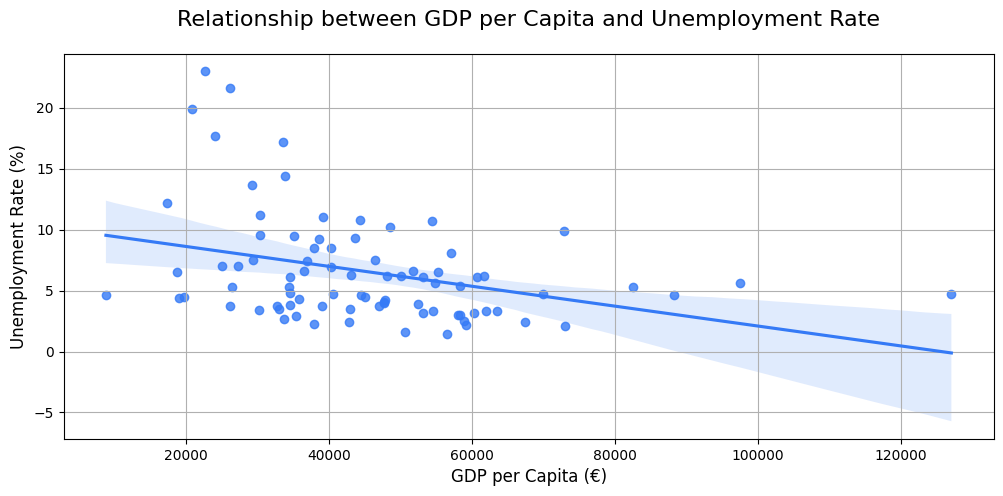

In [43]:
plt.figure(figsize=(12, 5))
#regplot includes the regression line
sns.regplot(x=dataset['GDP per Capita (€)'], y=dataset['Unemployment Rate'], color = '#357AF6')
plt.grid(True)
plt.title('Relationship between GDP per Capita and Unemployment Rate', fontsize=16, pad=20)
plt.xlabel('GDP per Capita (€)', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)

plt.show()

##### **Explanation**

The scatter plot illustrates the relationship between `GDP per Capita (€)` and the `Unemployment Rate (%)`. Each blue dot represents a record of a country and they show the distribution for both variables, with GDP per Capita ranging from approximately 15,000€ to over 120,000€, and the Unemployment Rate from lows of around 2% to extreme highs exceeding 20%.


Surrounding the blue line, there's this blue shaded area which represents the **confidence interval**, an important statistical component. This shadow does not represent the data points themselves, but rather the **uncertainty** in the line's prediction. Essentially, it shows the precision of the estimated relationship. Where the shadow is narrower (in the middle of the data cluster), the predicted relationship is **more precise**, where the shadow is wider (particularly at the extremes of the GDP per Capita axis), there is greater uncertainty in predicting the Unemployment Rate.

The most significant finding in this graph is the clear **negative relationship** between these two features, as we can visualise by the downward-sloping regression line. This means that as the **GDP per Capita increases, Unemployment Rate tends to decrease**. Therefore, countries with lower levels of GDP per capita tend to struggle with higher rates of unemployment.

We can also notice the presence of some outliers, the data points lying far outside of the confidence interval. The most notable ones involve countries with moderate GDP per Capita (€20,000 - €40,000) that have an exceptionally high unemployment rate (above 15%). These records highlight that the GDP per Capita variable is not sufficient to explain the distribution of the unemployment rate in all cases.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**3.b) Which are the top 5 cities with the largest difference between the Average Monthly Salary and Average Cost of Living? What about the top 5 countries with the smallest average difference? Show these results with meaningful visualizations.**

In [44]:
#here we will answer the first question
difference = dataset['Average Monthly Salary (€)'] - dataset['Average Cost of Living'] #calculates the differnce between the two varaibles
sorted_difference = difference.sort_values(ascending=False) #sortes the value in a desceding way. we now have the highest differences on head and the lowest on the tail
top_5_cities = sorted_difference.head().index.tolist()

print(f'The top 5 cities with the largest difference between the Average Monthly Salary and the Average Cost of Living are {', '.join(top_5_cities)}.')


The top 5 cities with the largest difference between the Average Monthly Salary and the Average Cost of Living are Basel, Tampere, Helsinki, Zurich, Geneva.


In [45]:
#answer to the second question
dataset['Difference (€)'] = dataset['Average Monthly Salary (€)'] - dataset['Average Cost of Living']
country_avg_difference = dataset.groupby('Country')['Difference (€)'].mean()
country_avg_difference_sorted = country_avg_difference.sort_values(ascending = True)
top_5_countries = country_avg_difference_sorted.head().index.tolist()

print(f'The top 5 countries with the smallest average difference between the Average Monthly Salary and the Average Cost of Living are {','.join(top_5_countries)}.')

The top 5 countries with the smallest average difference between the Average Monthly Salary and the Average Cost of Living are  Portugal, Greece, Slovak Republic, Turkiye, Poland.


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**3.c) Which is the best city for someone seeking:**
- an average monthly salary above €1600,
- a cost of living below €900, and
- a country suitable for starting a family (with a relatively larger youth population)?

We have one variable called `Youth Dependancy Ratio`that can helps us with the last topic (country with relatively larger youth population). We started to group the countries by the average of the young dependency ratio in the corresponding cities. \
As one of the requests is the city being in a country with a relatively larger population, we sorted that list and found the top 20 countries with the highest youth dependency ratio.

After analyzing many combinations, we concluded that **no city in our dataset meets all three initial conditions simultaneously**. This is likely because the requirement for a high salary (>1600€) and a very low cost of living (>900€) is mutually exclusive in most real-world economies. Therefore, we tried to find a realistic alternative: cities with the requested high salary (>1600€), located in a top 20 youth-populated country (using the top20_larger_youth_country variable), and then, ranked these results by the lowest cost of living to identify the best practical balance.

In [46]:
larger_youth_country = dataset.groupby('Country')['Youth Dependency Ratio'].mean()
sorted_larger_youth_country = larger_youth_country.sort_values(ascending= False)
top10_larger_youth_country = sorted_larger_youth_country.head(10)
top_countries_names = top10_larger_youth_country.index

In [47]:
filtered = dataset['Country'].isin(top_countries_names) #checks if the country of each city in the dataframe is in that list of the top 

In [48]:
best_city = ((dataset['Average Monthly Salary (€)'] > 1600)& (filtered))
best_city_found = dataset[best_city]

In [49]:
best_city_found_sorted = best_city_found.sort_values(
    by='Average Cost of Living', 
    ascending=True
)
best_city_found_sorted

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update,Country,Difference (€)
City,,,,,,,,,,,,,,
Gent,552.0,645813,417832.0,24.80,7.5,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17,Belgium,1200
Tallinn,2469.0,390860,253977.0,26.90,3.5,42916.23,0,"Estonian, Russian, English",1700,700,1600,2023-08-23,Estonia,100
Toulouse,4300.0,511684,401425.0,27.31,8.5,40216.62,14,French,2600,800,1600,2024-02-20,France,1000
Bruges,840.0,119765,74600.0,25.63,5.6,54882.21,0,"Dutch, French",2700,1250,1708,2023-10-25,Belgium,992
Lyon,10909.0,520774,365824.0,27.31,6.9,40216.62,11,French,2300,1200,1800,2023-03-31,France,500
Liverpool,1560.0,1544216,983056.0,26.80,7.5,29361.63,0,English,2250,950,1800,2024-01-23,United Kingdom,450
Brussels,681.0,3284548,2137425.0,27.50,10.7,54375.00,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22,Belgium,1450
Glasgow,548.0,1845020,1229657.0,24.20,4.8,34509.42,0,"English, Scots",2300,1050,1950,2023-05-28,United Kingdom,350
Antwerp,928.0,1139663,723396.0,27.70,6.2,50107.65,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09,Belgium,656


In [50]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84 entries, Vienna to Adana
Data columns (total 14 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Population Density (/km2)                84 non-null     float64       
 1   Population                               84 non-null     int64         
 2   Working Age Population (15-64 years)     84 non-null     float64       
 3   Youth Dependency Ratio                   84 non-null     float64       
 4   Unemployment Rate                        84 non-null     float64       
 5   GDP per Capita (€)                       84 non-null     float64       
 6   Days of very strong heat stress (>38ºC)  84 non-null     int64         
 7   Main Spoken Languages                    84 non-null     object        
 8   Average Monthly Salary (€)               84 non-null     int64         
 9   Average Rent Price (€)                   8

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**4.What are three additional insights you find meaningful when comparing the given cities?**

fazer maybe no final

<div style="background-color:#357AF6; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">
<h3><b>3. Working with Advanced Topics</b></h3>
    
**Building an Interactive Map**

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
The goal of this section is to create an interactive map of Europe where users can explore cities and view relevant information such as country, population, average salary, and cost of living. This task is divided into two main parts: **3.1 Web Scraping** and **3.2 Interative Map**


In [51]:
dataset.index

Index(['Vienna', 'Salzburg', 'Brussels', 'Antwerp', 'Gent', 'Bruges', 'Sofia',
       'Dobrich', 'Zurich', 'Geneva', 'Basel', 'Lefkosia', 'Lemesos', 'Prague',
       'Ostrava', 'Berlin', 'Hamburg', 'Munich', 'Cologne',
       'Frankfurt am Main', 'Stuttgart', 'Leipzig', 'Dresden', 'Dusseldorf',
       'Hanover', 'Copenhagen', 'Odense', 'Madrid', 'Barcelona', 'Valencia',
       'Seville', 'Malaga', 'Tallinn', 'Helsinki', 'Tampere', 'Paris', 'Lyon',
       'Toulouse', 'London', 'Leeds', 'Glasgow', 'Liverpool', 'Edinburgh',
       'Athens', 'Thessaloniki', 'Zagreb', 'Split', 'Budapest', 'Miskolc',
       'Debrecen', 'Dublin', 'Cork', 'Rome', 'Milan', 'Naples', 'Turin',
       'Florence', 'Venice', 'Luxembourg', 'Riga', 'Malta', 'The Hague',
       'Amsterdam', 'Rotterdam', 'Utrecht', 'Eindhoven', 'Oslo', 'Bergen',
       'Stavanger', 'Warsaw', 'Lodz', 'Cracow', 'Lisbon', 'Porto', 'Braga',
       'Coimbra', 'Giroc', 'Bratislava', 'Ljubljana', 'Stockholm',
       'Gothenburg', 'Malmo', 'Ank

In [52]:
dataset.rename(index = {'Gent': 'Ghent', 'Lefkosia': 'Nicosia', 'Lemesos': 'Limassol' }, inplace = True)
dataset.index
dataset.loc[['Ghent']]

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update,Country,Difference (€)
City,,,,,,,,,,,,,,
Ghent,552.0,645813,417832.0,24.8,7.5,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17,Belgium,1200


In [53]:
dataset.loc['Ostrava']

Population Density (/km2)                                499.0
Population                                              711860
Working Age Population (15-64 years)                  464578.0
Youth Dependency Ratio                                    23.0
Unemployment Rate                                          3.7
GDP per Capita (€)                                    26191.35
Days of very strong heat stress (>38ºC)                      0
Main Spoken Languages                                    Czech
Average Monthly Salary (€)                                1520
Average Rent Price (€)                                     500
Average Cost of Living                                    1100
Last Data Update                           2023-09-21 00:00:00
Country                                                Czechia
Difference (€)                                             420
Name: Ostrava, dtype: object

### Web Scraping


In [58]:
import time
from selenium.webdriver.chrome.options import Options #interact with page


options = Options()
options.add_argument("--start-maximized")
browser = webdriver.Chrome(options=options)
browser.get("https://en.wikipedia.org/wiki/Main_Page")
time.sleep(3)  # wait for 3 seconds to let the page load





#preciso de criar um for loop para obter as coordenadas de todas as cities, num loop
for city, row in dataset.iterrows():
    
    country = row['Country']
    

    search_bar = browser.find_elements(By.CSS_SELECTOR, '.cdx-text-input__input')
    search_bar[0].clear()
    search_bar[0].send_keys(city, ",", country)
    time.sleep(2)  # wait for 2 seconds to let the suggestions load

    first_result = browser.find_elements(By.CLASS_NAME, 'cdx-menu-item__content')
    if first_result:
        first_result[0].click()
        time.sleep(2)  # wait for 2 seconds to let the page load
        soup = BeautifulSoup(browser.page_source, 'html.parser')
        coord_list = soup.find_all('span', class_='geo-dms')
        coord = coord_list[0]
        if coord:
            print(f"{city}: {coord.text}")
        else:
            print(f"{city}: Coordinates not found")
    else:
        print(f"{city}: No search results found")

browser.quit()
    





Vienna: 48°12′30″N 16°22′21″E
Salzburg: 47°48′00″N 13°02′42″E
Brussels: 50°50′48″N 04°21′09″E
Antwerp: 51°13′04″N 04°24′01″E
Ghent: 51°03′13″N 03°43′31″E
Bruges: 51°12′32″N 03°13′27″E
Sofia: 42°42′N 23°20′E
Dobrich: 43°34′N 27°50′E
Zurich: 47°22′28″N 08°32′28″E
Geneva: 46°12′06″N 06°08′49″E
Basel: 47°33′17″N 07°35′26″E
Nicosia: 35°10′21″N 33°21′54″E
Limassol: 34°40′29″N 33°02′39″E
Prague: 50°5′15″N 14°25′17″E
Ostrava: 49°50′8″N 18°17′33″E
Berlin: 52°31′12″N 13°24′18″E
Hamburg: 53°33′N 10°00′E
Munich: 48°08′15″N 11°34′30″E
Cologne: 50°56′11″N 6°57′10″E
Frankfurt am Main: 50°06′38″N 08°40′56″E
Stuttgart: 48°46′39″N 09°10′48″E
Leipzig: 51°20′24″N 12°22′30″E
Dresden: 51°03′00″N 13°44′24″E
Dusseldorf: 51°13′32″N 6°46′36″E
Hanover: 52°22′N 9°43′E
Copenhagen: 55°40′34″N 12°34′06″E
Odense: 55°23′45″N 10°23′19″E


IndexError: list index out of range

### Interactive Map

In [ ]:
!pip install plotly
import plotly.express as px
import pandas as pd

interactive_dataset = dataset.copy()   

interactive_dataset['hover'] = (
    'City: ' + interactive_dataset['City'].astype(str) +
    '<br>Country: ' + interactive_dataset['Country'].astype(str) +
    '<br>Population: ' + interactive_dataset['Population'].astype(str) +
    '<br>Average Monthly Salary (€): ' + interactive_dataset['Average Monthly Salary (€)'].astype(str) +
    '<br>Average Cost of Living: ' + interactive_dataset['Average Cost of Living'].astype(str)
)

figure = px.scatter_geo(
    interactive_dataset,
    latitude = 'Latitude',
    longitude = 'Longitude',
    text = 'City',              
    hover_name = 'City',       
    hover_data = {'hover': True, 'Latitude': False, 'Longitude': False},
    projection = 'natural earth'
)

fig.update_traces(
    marker = dict(size = 10, color = 'blue'),
    hovertemplate = interactive_dataset['hover']
)

fig.update_layout(
    title = 'Interactive Map of European Cities',
    geo = dict(
        scope = 'europe',
        landcolor = 'lightgray',
        showland = True,
    ),
    margin = {'r':0,'t':40,'l':0,'b':0}
)

fig.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">
<h3><b>4. Data Science in Action: Framework and Conclusions</b></h3>


# 